# FRLC Experiments

This tutorial reproduces the main experimental findings of the paper by P. Halmos and al. using the OTT-JAX library.

Tutorial by Gabriel Tang


## Imports

In [2]:
import functools
from typing import Any, Callable

import jax
import jax.numpy as jnp
import numpy as np

import matplotlib.pyplot as plt
from IPython import display

import ott
from ott.geometry import geometry, pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn
from ott.tools import plot, sinkhorn_divergence

In [17]:
key = jax.random.PRNGKey(0)
eps = 1e-16

## FRLC

### Couplings Initialization

In [ ]:
## Initialization algorithm for Q, R and T (Algorithm 6 in the paper)


def initialize_couplings(a, b, gq, gr):
    """
    Initialize LC factorized OT couplings using Sinkhorn.

    Args:
        a: (n,) source marginal
        b: (m,) target marginal
        gq: (r,) latent marginal (Q-side)
        gr: (r,) latent marginal (R-side)
        key: jax random key

    Returns:
        Q: (n, r) coupling between a and gq
        R: (m, r) coupling between b and gr
        T: (r, r) latent coupling between gq and gr
    """

    n, m, r = len(a), len(b), len(gq)
    assert r == len(gr)

    key_q, key_r, key_t = jax.random.split(key, 3)

    Cq = jax.random.uniform(key_q, (n, r))
    Cr = jax.random.uniform(key_r, (m, r))
    Ct = jax.random.uniform(key_t, (r, r))

    geomq = geometry.Geometry(cost_matrix=Cq, epsilon=0.1)
    geomr = geometry.Geometry(cost_matrix=Cr, epsilon=0.1)
    geomt = geometry.Geometry(cost_matrix=Ct, epsilon=0.1)

    problemq = linear_problem.LinearProblem(geomq, a=a, b=gq)
    problemr = linear_problem.LinearProblem(geomr, a=b, b=gr)
    solver = sinkhorn.Sinkhorn()
    Q = solver(problemq).matrix
    R = solver(problemr).matrix

    gq_bis = Q.T @ jnp.ones(n)
    gr_bis = R.T @ jnp.ones(m)
    problemt = linear_problem.LinearProblem(geomt, a=gq_bis, b=gr_bis)
    T = solver(problemt).matrix

    return Q, R, T

In [19]:
## Test of the function


key = jax.random.PRNGKey(0)

n, m, r = 5, 4, 3

a = jnp.ones(n) / n
b = jnp.ones(m) / m
gq = jnp.ones(r) / r
gr = jnp.ones(r) / r

Q, R, T = initialize_couplings(a, b, gq, gr)

print("Q shape:", Q.shape)
print("R shape:", R.shape)
print("T shape:", T.shape)

print("Q sum:", Q.sum())
print("R sum:", R.sum())
print("T sum:", T.sum())

Q shape: (5, 3)
R shape: (4, 3)
T shape: (3, 3)
Q sum: 0.9999998
R sum: 0.99999994
T sum: 0.9999998


### Convergence Criterion

In [21]:
import jax.numpy as jnp


def delta_k(Q_k, Q_k1, R_k, R_k1, T_k, T_k1, gamma_k, first_iter=False):
    """
    Compute convergence criterion Δ_k for LC-parametrization.

    Args:
        Q_k, Q_k1: (n, r)
        R_k, R_k1: (m, r)
        T_k, T_k1: (r, r)
        gamma_k: scalar step size

    Returns:
        scalar Δ_k
    """

    def first_case(_):
        return jnp.array(1.0)

    def normal_case(_):
        dQ = jnp.sum((Q_k1 - Q_k) ** 2)
        dR = jnp.sum((R_k1 - R_k) ** 2)
        dT = jnp.sum((T_k1 - T_k) ** 2)
        return (dQ + dR + dT) / ((gamma_k + eps) ** 2)

    return jax.lax.cond(first_iter, first_case, normal_case, operand=None)

### Update Couplings

Kernels resulting from factor relaxation step

#### Compute Gradients

In [22]:
def grad_Q(Q, R, X, C, gQ):
    CRXT = C @ R @ X.T
    norm = jnp.diagonal((CRXT.T @ Q) / gQ)
    B = jnp.ones((Q.shape[0], 1)) @ norm[None, :]
    return CRXT - B

In [23]:
def grad_R(Q, R, X, C, gR):
    CTQX = C.T @ Q @ X
    norm = jnp.diagonal((R.T @ CTQX) / (gR + eps))
    B = jnp.ones((R.shape[0], 1)) @ norm[None, :]
    return CTQX - B

In [24]:
def grad_T(Q, R, C, gQ, gR):
    QTCR = Q.T @ C @ R
    grad = QTCR / (gQ[:, None] + eps) / (gR[None, :] + eps)
    return grad

#### Semi-relaxed OT

In [ ]:
from jax import lax


def srr_projection(geom, a, b, gamma, tau, delta, max_iter=50000):

    exponent = tau / (tau + (1 / (gamma + eps)) + eps)

    # init
    def init_state():
        u = jnp.ones_like(a)
        v = jnp.ones_like(b)
        it = 0
        crit = jnp.inf
        return (u, v, it, crit)

    # condition
    def cond_fun(state):
        u, v, it, crit = state
        return jnp.logical_and(crit > delta, it < max_iter)

    # step
    def body_fun(state):
        u, v, it, _ = state

        # update u
        Kv = geom.apply_kernel(v, axis=1)
        u_new = a / (Kv + eps)

        # update v
        KTu = geom.apply_kernel(u_new, axis=0)
        v_new = (b / (KTu + eps)) ** exponent

        # convergence test (IMPORTANT: same step)
        diff_u = jnp.max(jnp.abs(jnp.log((u_new + eps) / (u + eps))))
        diff_v = jnp.max(jnp.abs(jnp.log((v_new + eps) / (v + eps))))
        crit = jnp.maximum(diff_u, diff_v) / gamma

        return (u_new, v_new, it + 1, crit)

    # run loop
    u, v, it, crit = lax.while_loop(cond_fun, body_fun, init_state())

    # transport
    transport = u[:, None] * geom.kernel_matrix * v[None, :]

    return u, v, transport

In [26]:
## Test of SRR:


key_test = jax.random.PRNGKey(0)

n, m = 50, 60
x = jax.random.normal(key_test, (n, 2))
y = jax.random.normal(key_test, (m, 2))

a = jnp.ones(n) / n
b = jnp.ones(m) / m

geom = pointcloud.PointCloud(x, y, epsilon=1e-1)

# Run SRR
u, v, transport_fn = srr_projection(geom, a, b, gamma=2.0, tau=0.5, delta=1e-6)

P = transport_fn

# Verifications

# 1. Mass transportée
mass = P.sum()
print("Total mass:", mass)

# 2. Marginale gauche (doit matcher a)
left_marginal = P.sum(axis=1)
err_left = jnp.linalg.norm(left_marginal - a, ord=1)

print("Erreur marginale gauche (L1):", err_left)

# 3. Marginale droite (relaxée → pas exacte)
right_marginal = P.sum(axis=0)
err_right = jnp.linalg.norm(right_marginal - b, ord=1)

print("Erreur marginale droite (L1):", err_right)

# 4. Vérif positivité
print("Min(P):", P.min(), "Max(P):", P.max())

# 5. Sanity check scaling
print("u stats:", u.min(), u.max())
print("v stats:", v.min(), v.max())

Total mass: 0.99999976
Erreur marginale gauche (L1): 3.054738e-07
Erreur marginale droite (L1): 0.17147204
Min(P): 0.0 Max(P): 0.01999997
u stats: 0.0023902804 0.023999944
v stats: 0.78014374 207.32889


We observe that $\max v >>\max u$. Since the right marginal is relaxed the right marginal error is significantly higher than left marginal error, as it is expected.

### Main Loop

Since for high rank value the criterions tends to be very small at the first iterations we integrate a minimal number of iterations to do before convergence. To avoid nan values we add an epsilon to each variable divded.

In [ ]:
from jax import debug, lax


def frlc_loop_fast(
    C,
    r,
    a,
    b,
    gamma,
    tau,
    delta,
    epsilon=1e-6,
    max_iter=5000,
    eps_sinkhorn=1e-2,
    min_iter=0,
    debugging=False,
):

    eps = 1e-12

    ones_n = jnp.ones_like(a)
    ones_m = jnp.ones_like(b)

    def init_state():
        gr = jnp.ones(r) / r
        gq = gr

        Q, R, T = initialize_couplings(a, b, gr, gq)

        X = (1 / (Q.T @ ones_n))[:, None] * T * (1 / (R.T @ ones_m))[None, :]

        return {
            "it": 0,
            "Q": Q,
            "R": R,
            "T": T,
            "Qprev": Q,
            "Rprev": R,
            "Tprev": T,
            "gq": gq,
            "gr": gr,
            "X": X,
            "gamma_k": gamma,
            "first": True,
        }

    def cond_fun(state):
        crit = delta_k(
            state["Q"],
            state["Qprev"],
            state["R"],
            state["Rprev"],
            state["T"],
            state["Tprev"],
            state["gamma_k"],
            first_iter=state["first"],
        )

        if debugging:
            debug.print("crit={crit}", crit=crit)

        stop_cond = jnp.logical_and(crit > epsilon, state["it"] < max_iter)
        return jnp.logical_or(state["it"] < min_iter, stop_cond)

    def body_fun(state):

        Q, R, T = state["Q"], state["R"], state["T"]
        gq, gr = state["gq"], state["gr"]
        X = state["X"]

        # --- gradients
        gradQ = grad_Q(Q, R, X, C, gq)
        gradR = grad_R(Q, R, X, C, gr)

        scale = jnp.maximum(
            jnp.max(jnp.abs(gradQ)),
            jnp.max(jnp.abs(gradR)),
        )

        gamma_k = gamma / jnp.maximum(scale, eps)

        KQ = Q * jnp.exp(-gamma_k * gradQ)
        KR = R * jnp.exp(-gamma_k * gradR)

        geomQ = geometry.Geometry(kernel_matrix=KQ, epsilon=eps_sinkhorn)
        geomR = geometry.Geometry(kernel_matrix=KR, epsilon=eps_sinkhorn)

        Qprev, Rprev = Q, R

        _, _, Q = srr_projection(
            geomQ, a, Qprev.T @ ones_n, gamma_k, tau, delta
        )

        _, _, R = srr_projection(
            geomR, b, Rprev.T @ ones_m, gamma_k, tau, delta
        )

        gq_new = Q.T @ ones_n
        gr_new = R.T @ ones_m

        # --- T update
        gradT = grad_T(Q, R, C, gq_new, gr_new)

        if debugging:
            debug.print("NaN in gradT? {}", jnp.isnan(T).any())

        gamma_t = gamma / jnp.maximum(eps, jnp.max(jnp.abs(gradT)))
        KT = T * jnp.exp(-gamma_t * gradT)

        geomT = geometry.Geometry(kernel_matrix=KT, epsilon=eps_sinkhorn)

        problemt = linear_problem.LinearProblem(geomT, a=gq_new, b=gr_new)

        solver = sinkhorn.Sinkhorn(threshold=delta)
        Tprev = T
        T = solver(problemt).matrix

        X = (1 / jnp.maximum(gq_new, eps))[:, None] * T * (
            1 / jnp.maximum(gr_new + eps)
        )[None, :] + eps

        if debugging:
            debug.print(
                "it={it} gamma_k={gk} max_gradQ={mq} max_gradR={mr}",
                it=state["it"],
                gk=gamma_k,
                mq=jnp.max(jnp.abs(gradQ)),
                mr=jnp.max(jnp.abs(gradR)),
            )

        return {
            "it": state["it"] + 1,
            "Q": Q,
            "R": R,
            "T": T,
            "Qprev": Qprev,
            "Rprev": Rprev,
            "Tprev": Tprev,
            "gq": gq_new,
            "gr": gr_new,
            "X": X,
            "gamma_k": gamma_k,
            "first": False,
        }

    state = lax.while_loop(cond_fun, body_fun, init_state())

    return (
        state["Q"] @ state["X"] @ state["R"].T,
        state["Q"],
        state["R"],
        state["T"],
    )

In [ ]:
# Toy problem setup
key = jax.random.PRNGKey(0)

n, m = 10, 12
r = 5

a = jnp.ones(n) / n
b = jnp.ones(m) / m

# cost matrix (random but structured)
x = jax.random.normal(key, (n, 2))
y = jax.random.normal(key, (m, 2))
C = jnp.sum((x[:, None, :] - y[None, :, :]) ** 2, axis=-1)

# hyperparameters
gamma = 1
tau = 0.5
delta = 1e-6

# Run function
P, _, _, _ = frlc_loop_fast(
    C=C,
    r=r,
    a=a,
    b=b,
    gamma=gamma,
    tau=tau,
    delta=delta,
    epsilon=1e-6,
    eps_sinkhorn=1e-4,
    max_iter=10000,
)

In [29]:
P @ y

Array([[ 0.02109006,  0.10026442],
       [ 0.02109006,  0.10026439],
       [ 0.06279353, -0.12003659],
       [ 0.02109006,  0.10026442],
       [ 0.06279353, -0.12003659],
       [ 0.06279355, -0.12003661],
       [ 0.02109006,  0.10026442],
       [ 0.02109006,  0.10026442],
       [ 0.02109006,  0.10026442],
       [ 0.06279353, -0.12003659]], dtype=float32)

In [30]:
# ----------------------------
# Basic checks
# ----------------------------
print("Output shape:", P.shape)
assert P.shape == (n, m), "❌ Output has wrong shape"

# non-negativity (OT should be >= 0 approx)
print("Min value:", P.min())
assert jnp.all(P >= -1e-5), "❌ Transport plan has negative values"

# mass check (approx doubly stochastic-like depending on model)
row_sums = P.sum(axis=1)
col_sums = P.sum(axis=0)

print("Row sums (first 5):", row_sums[:5])
print("Col sums (first 5):", col_sums[:5])

assert jnp.all(jnp.isfinite(P)), "❌ NaN or Inf detected"

# sanity: not completely degenerate
assert P.sum() > 0, "❌ Degenerate solution (all zeros)"

print("✅ frlc_loop test passed successfully")

Output shape: (10, 12)
Min value: 8.333334e-15
Row sums (first 5): [0.10000002 0.10000001 0.10000002 0.10000002 0.10000002]
Col sums (first 5): [0.08333332 0.08333337 0.08333337 0.08333332 0.08333337]
✅ frlc_loop test passed successfully


## Experiments

We now have the proof that the FRLC algorithm converges well for a simple exemple (few samples). Now let's use it to estimate more complicated transport plans.

### Datasets Generators

As in the original paper we test FRLC on two type of synthetic data:
- Two moons (clusters are non linear manifolds)
- Gaussians (data distribution is multimodal gaussian. CLusters are placed on a circle)

In [31]:
def plot_dataset(X, title="Dataset", ax=None, color="blue"):
    # conversion éventuelle DeviceArray → numpy (matplotlib aime mieux)
    X_np = jnp.asarray(X)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    ax.scatter(X_np[:, 0], X_np[:, 1], s=10, alpha=0.8, c=color)
    ax.set_title(title)
    ax.set_aspect("equal")

    return ax

In [32]:
def make_moons(n=500, noise=0.05, key=jax.random.PRNGKey(0)):
    n_half = n // 2

    theta = jnp.linspace(0.0, jnp.pi, n_half)

    x1 = jnp.stack([jnp.cos(theta) - 0.5, jnp.sin(theta) - 0.25], axis=1)
    x2 = jnp.stack(
        [1 - jnp.cos(theta) - 0.5, 1 - jnp.sin(theta) - 0.75], axis=1
    )

    X = jnp.concatenate([x1, x2], axis=0)
    print(x1.shape, x2.shape, X.shape)

    # bruit JAX
    key, subkey = jax.random.split(key)
    noise_term = noise * jax.random.normal(subkey, shape=X.shape)

    return X + noise_term

(250, 2) (250, 2) (500, 2)


<Axes: title={'center': 'Moons Dataset'}>

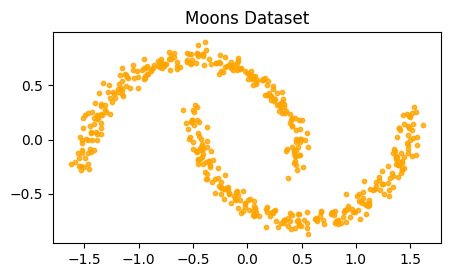

In [33]:
test_moons = make_moons(n=500)
plot_dataset(test_moons, title="Moons Dataset", ax=None, color="orange")

In [34]:
test_moons.shape

(500, 2)

In [35]:
def make_gaussians(
    n=500, noise=0.1, key=jax.random.PRNGKey(0), nb_gaussians=10, radius=2.0
):

    angles = jnp.linspace(0.0, 2 * jnp.pi, nb_gaussians, endpoint=False)
    centers = jnp.stack([jnp.cos(angles), jnp.sin(angles)], axis=1) * radius

    indices = jnp.arange(n) % nb_gaussians
    assigned_centers = centers[indices]

    key, subkey = jax.random.split(key)
    noise_term = noise * jax.random.normal(subkey, shape=(n, 2))

    return assigned_centers + noise_term

<Axes: title={'center': '10 Gaussians Dataset'}>

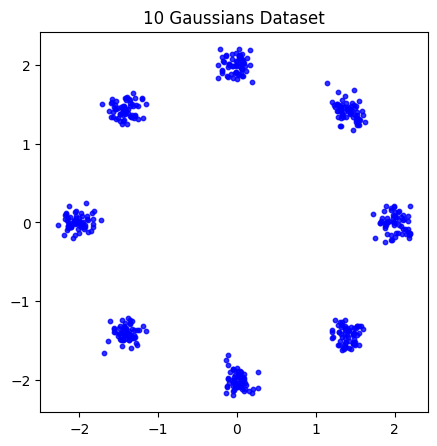

In [36]:
test_gaussians = make_gaussians(n=500, nb_gaussians=8)
plot_dataset(
    test_gaussians, title="10 Gaussians Dataset", ax=None, color="blue"
)

### Functions to run algorithm

We are going to compare our FRLC algorithm to Sinkhorn

In [37]:
def run_sinkhorn(x, y):
    geom = pointcloud.PointCloud(x, y, epsilon=0.05)
    prob = linear_problem.LinearProblem(geom)

    solver = sinkhorn.Sinkhorn()
    out = solver(prob)

    return out.matrix

In [49]:
from ott.solvers.linear import sinkhorn_lr


def run_lrsinkhorn(x, y, rlr=20, epsilon=1e-2):

    n = x.shape[0]
    m = y.shape[0]
    C = jnp.sum((x[:, None, :] - y[None, :, :]) ** 2, axis=2)
    C = C / jnp.mean(C)

    geom = geometry.Geometry(cost_matrix=C, epsilon=epsilon)
    a = jnp.ones(n) / n
    b = jnp.ones(m) / m

    problem = linear_problem.LinearProblem(geom, a=a, b=b)
    solver = sinkhorn_lr.LRSinkhorn(rank=rlr)
    out = solver(problem)

    return out.matrix, out.q, out.r, out.g

In [39]:
def run_frlc(x, y, r=20, gamma=1, tau=0.5, min_iter=0, debugging=False):
    n = x.shape[0]
    m = y.shape[0]

    # coût
    C = jnp.sum((x[:, None, :] - y[None, :, :]) ** 2, axis=2)
    C = C / jnp.mean(C)

    a = jnp.ones(n) / n
    b = jnp.ones(m) / m

    return (
        frlc_loop_fast(
            C=C,
            r=r,
            a=a,
            b=b,
            gamma=gamma,
            tau=tau,
            delta=1e-6,
            epsilon=1e-6,
            min_iter=min_iter,
            debugging=debugging,
        ),
        C,
    )

In [50]:
def experiment(x, y, r, min_iter=0, debugging=False):
    P_sink = run_sinkhorn(x, y)
    frlc, C_euclidian = run_frlc(
        x, y, r=r, min_iter=min_iter, debugging=debugging
    )
    P_frlc = frlc[0]
    lrsink = run_lrsinkhorn(x, y, rlr=r)
    P_lrsink = lrsink[0]

    fig, axs = plt.subplots(1, 2, figsize=(15, 4))

    axs[0].scatter(x[:, 0], x[:, 1], s=5, color="orange", label="source data")
    axs[0].scatter(y[:, 0], y[:, 1], s=5, color="blue", label="target data")
    axs[0].legend()
    axs[0].set_title(f"Synthetic Data")

    # barycentres transportés
    Tx_sink = P_sink @ y
    Tx_frlc = P_frlc @ y
    Tx_lrsink = P_lrsink @ y

    axs[1].scatter(
        Tx_sink[:, 0], Tx_sink[:, 1], s=5, label="Sinkhorn", alpha=0.5
    )
    axs[1].scatter(Tx_frlc[:, 0], Tx_frlc[:, 1], s=5, label="FRLC", alpha=0.5)
    axs[1].scatter(
        Tx_lrsink[:, 0], Tx_lrsink[:, 1], s=5, label="LR Sinkhorn", alpha=0.5
    )
    axs[1].legend()
    axs[1].set_title("Transport Barycenters")

    plt.show()

    C = C_euclidian
    print("Total Costs:")
    print(" - Sinkhorn", jnp.sum(P_sink * C))
    print(" - LR Sinkhorn", jnp.sum(P_lrsink * C))
    print(" - FRLC", jnp.sum(P_frlc * C))

### Experiment 1:
Test of FRLC on synthetic dataset with a fixed rank r

(500, 2) (500, 2) (1000, 2)


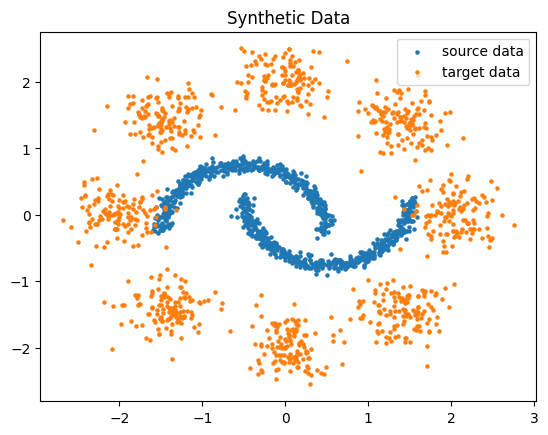

In [41]:
# Generate Data
x = make_moons(1000)
y = make_gaussians(1000, nb_gaussians=8, noise=0.25)

plt.figure()

plt.scatter(x[:, 0], x[:, 1], s=5, label="source data")

plt.scatter(y[:, 0], y[:, 1], s=5, label="target data")
plt.legend()
plt.title("Synthetic Data")
plt.show()

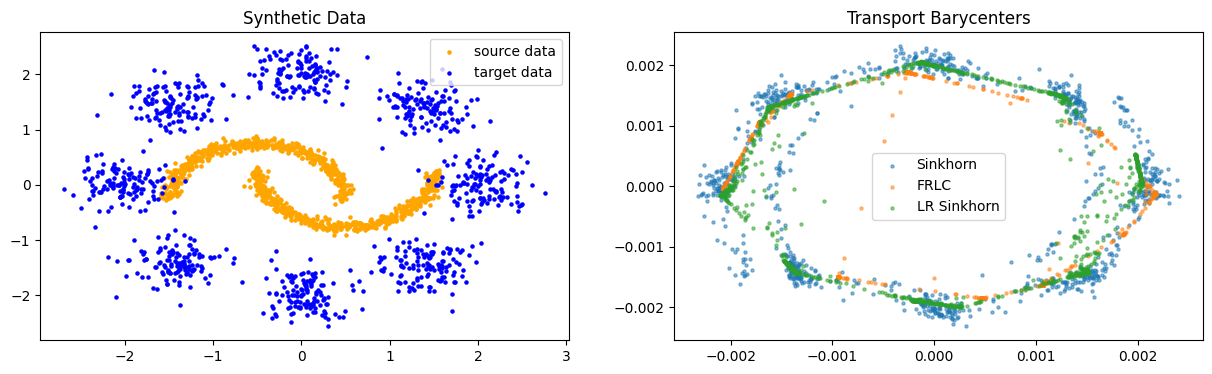

Total Costs:
 - Sinkhorn 0.2891825
 - LR Sinkhorn 0.31810462
 - FRLC 0.35496888


In [42]:
experiment(x, y, 20, min_iter=100)

### Experiment 2

Evolution of cost with rank for Low Rank Sinkhorn et FRLC

#### Function

In [5]:
def experiment_cost_vs_rank(
    x,
    y,
    ranks,
    min_iter=0,
    debugging=False,
    figsize=(8, 5),
):
    """
    Displays evolution of OT cost with respect to r for FRLC and LR Sinkhorn

    Parameters
    ----------
    x, y : arrays
        Données source et cible.

    ranks : iterable
        Liste des rangs à tester.

    min_iter : int
        Nombre minimal d'itérations FRLC.

    debugging : bool
        Active les prints de debug FRLC.

    figsize : tuple
        Taille de la figure.
    """

    # Sinkhorn cost
    P_sink = run_sinkhorn(x, y)

    # stockage
    frlc_costs = []
    lrsink_costs = []

    for r in ranks:

        print(f"Running rank r={r}")

        # ---------- FRLC ----------
        frlc, C = run_frlc(x, y, r=r, min_iter=min_iter, debugging=debugging)

        P_frlc = frlc[0]

        cost_frlc = jnp.sum(P_frlc * C)
        frlc_costs.append(float(cost_frlc))

        # ---------- LR Sinkhorn ----------
        P_lrsink, _, _, _ = run_lrsinkhorn(x, y, rlr=r)

        cost_lrsink = jnp.sum(P_lrsink * C)
        lrsink_costs.append(float(cost_lrsink))

        print(
            f"r={r:3d} | "
            f"FRLC={cost_frlc:.6f} | "
            f"LR Sinkhorn={cost_lrsink:.6f}"
        )

    # ---------- Plot ----------
    plt.figure(figsize=figsize)

    plt.plot(ranks, frlc_costs, marker="o", label="FRLC")

    plt.plot(ranks, lrsink_costs, marker="s", label="LR Sinkhorn")

    # Sinkhorn reference
    sink_cost = jnp.sum(P_sink * C)
    plt.axhline(y=float(sink_cost), linestyle="--", label="Sinkhorn")

    plt.xlabel("Rank r")
    plt.ylabel("Transport Cost")
    plt.title("Cost vs Rank")

    plt.legend()

    plt.grid(True)

    plt.show()

    return {
        "ranks": ranks,
        "frlc_costs": frlc_costs,
        "lrsink_costs": lrsink_costs,
        "sinkhorn_cost": float(sink_cost),
    }

#### End Function

Running rank r=20
r= 20 | FRLC=0.354969 | LR Sinkhorn=0.318105
Running rank r=30
r= 30 | FRLC=0.357525 | LR Sinkhorn=0.315905
Running rank r=40
r= 40 | FRLC=0.339425 | LR Sinkhorn=0.317187
Running rank r=50
r= 50 | FRLC=0.330561 | LR Sinkhorn=0.318311
Running rank r=60
r= 60 | FRLC=0.339256 | LR Sinkhorn=0.313728
Running rank r=70
r= 70 | FRLC=0.339470 | LR Sinkhorn=0.317327
Running rank r=80
r= 80 | FRLC=0.344048 | LR Sinkhorn=0.310325
Running rank r=90
r= 90 | FRLC=0.336940 | LR Sinkhorn=0.315792
Running rank r=100
r=100 | FRLC=0.331351 | LR Sinkhorn=0.310174
Running rank r=110
r=110 | FRLC=0.335075 | LR Sinkhorn=0.310823
Running rank r=120
r=120 | FRLC=0.327715 | LR Sinkhorn=0.309790
Running rank r=130
r=130 | FRLC=0.333614 | LR Sinkhorn=0.311307
Running rank r=140
r=140 | FRLC=0.325889 | LR Sinkhorn=0.309957
Running rank r=150
r=150 | FRLC=0.319266 | LR Sinkhorn=0.310911
Running rank r=160
r=160 | FRLC=0.323976 | LR Sinkhorn=0.311318
Running rank r=170
r=170 | FRLC=0.333857 | LR Si

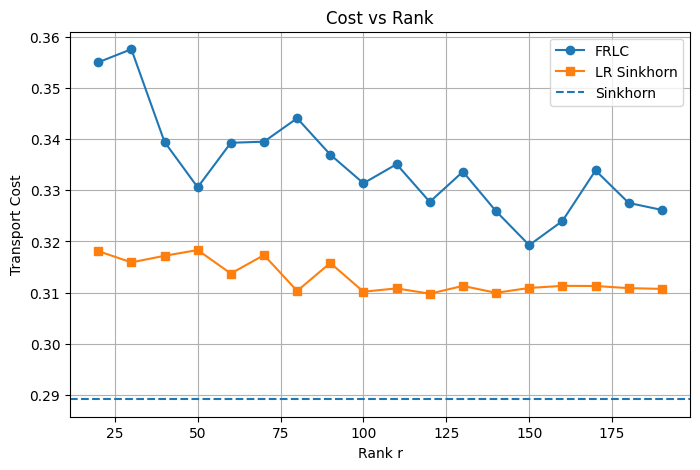

In [ ]:
ranks = np.arange(18) * 10 + 20

results = experiment_cost_vs_rank(x, y, ranks=ranks, min_iter=100)

We observe that FRLC cost diminishes with the rank, the LR Sinkhorn cost is constant and this algorithm performs better than the presented implementation of FRLC. Refinements of the algorithm may be needed so the FRLC performs better than simple LR Sinkhorn. Also classical Sinkhorn outperforms both models.

### Experiment 3

Let's vizualise the Latent Coupling Projection (displays a visual representation of learned latent coupling
and corresponding barycenters).


#### Function

In [74]:
def experiment_latent_couplings_compare(
    x,
    y,
    ranks=(5, 10),
    min_iter=50,
    debugging=False,
    point_alpha=0.25,
    coupling_alpha=0.35,
    num_paths=1000,
    key=key,
):
    """
    Compare :
        - Ground truth Sinkhorn
        - FRLC latent couplings
        - LR Sinkhorn latent couplings

    Pour chaque rang r :
        colonne gauche  : FRLC
        colonne droite  : LR Sinkhorn
    """

    eps = 1e-12

    # Ground truth Sinkhorn

    P_sink = run_sinkhorn(x, y)

    ncols = 1 + 2 * len(ranks)

    fig, axs = plt.subplots(1, ncols, figsize=(5 * ncols, 5))
    ax = axs[0]

    ax.scatter(x[:, 0], x[:, 1], s=8, alpha=point_alpha, label="Source")

    ax.scatter(y[:, 0], y[:, 1], s=8, alpha=point_alpha, label="Target")

    # Flatten the transport matrix into probabilities
    probs = P_sink.reshape(-1)
    probs = probs / probs.sum()

    key, subkey = jax.random.split(key)

    flat_indices = jax.random.choice(
        subkey, a=probs.size, shape=(num_paths,), p=probs, replace=False
    )

    # Convert flat indices back to (i,j)
    rows, cols = jnp.unravel_index(flat_indices, P_sink.shape)

    Pmax = jnp.max(P_sink)

    for i, j in zip(rows, cols):

        w = P_sink[i, j]

        ax.plot(
            [x[i, 0], y[j, 0]],
            [x[i, 1], y[j, 1]],
            alpha=float(coupling_alpha * w / Pmax),
            color="green",
        )

    ax.set_title("Ground Truth\n(Sinkhorn)")
    ax.legend()

    # Loop over ranks
    for idx, r in enumerate(ranks):

        # FRLC

        ax_frlc = axs[1 + 2 * idx]

        frlc, C = run_frlc(x, y, r=r, min_iter=min_iter, debugging=debugging)

        P_frlc = frlc[0]
        Qf = frlc[1]
        Rf = frlc[2]
        Tf = frlc[3]

        # latent masses
        gqf = Qf.T @ jnp.ones(Qf.shape[0])
        grf = Rf.T @ jnp.ones(Rf.shape[0])

        # LC projections
        Yxf = (Qf.T @ x) / (gqf[:, None] + eps)
        Yyf = (Rf.T @ y) / (grf[:, None] + eps)

        # clouds
        ax_frlc.scatter(x[:, 0], x[:, 1], s=8, alpha=point_alpha)

        ax_frlc.scatter(y[:, 0], y[:, 1], s=8, alpha=point_alpha)

        # latent points
        ax_frlc.scatter(
            Yxf[:, 0], Yxf[:, 1], s=70, marker="o", label="Latent source"
        )

        ax_frlc.scatter(
            Yyf[:, 0], Yyf[:, 1], s=70, marker="x", label="Latent target"
        )

        # latent coupling
        Tmaxf = jnp.max(Tf)

        for i in range(Tf.shape[0]):
            for j in range(Tf.shape[1]):

                w = Tf[i, j]
                ax_frlc.plot(
                    [Yxf[i, 0], Yyf[j, 0]],
                    [Yxf[i, 1], Yyf[j, 1]],
                    alpha=float(coupling_alpha * w / Tmaxf),
                    color="green",
                )

        cost_frlc = jnp.sum(P_frlc * C)

        ax_frlc.set_title(f"FRLC Rank {r}\nCost={float(cost_frlc):.4f}")

        ax_frlc.legend()

        # LR Sinkhorn

        ax_lr = axs[1 + 2 * idx + 1]

        lrs = run_lrsinkhorn(
            x,
            y,
            rlr=r,
        )

        P_lr = lrs[0]
        Ql = lrs[1]
        Rl = lrs[2]
        gl = lrs[3]

        # latent projections
        Yxl = (Ql.T @ x) / (gl[:, None] + eps)
        Yyl = (Rl.T @ y) / (gl[:, None] + eps)

        # clouds
        ax_lr.scatter(x[:, 0], x[:, 1], s=8, alpha=point_alpha)

        ax_lr.scatter(y[:, 0], y[:, 1], s=8, alpha=point_alpha)

        # latent points
        ax_lr.scatter(
            Yxl[:, 0], Yxl[:, 1], s=70, marker="o", label="Latent source"
        )

        ax_lr.scatter(
            Yyl[:, 0], Yyl[:, 1], s=70, marker="x", label="Latent target"
        )

        # latent coupling
        gmaxl = jnp.max(gl)

        for i in range(len(gl)):
            w = gl[i]
            if w > 0.05 * gmaxl:
                ax_lr.plot(
                    [Yxl[i, 0], Yyl[i, 0]],
                    [Yxl[i, 1], Yyl[i, 1]],
                    alpha=float(coupling_alpha * w / gmaxl),
                    color="green",
                )

        cost_lr = jnp.sum(P_lr * C)

        ax_lr.set_title(f"LR Sinkhorn Rank {r}\nCost={float(cost_lr):.4f}")

        ax_lr.legend()

    plt.tight_layout()
    plt.show()

#### End Function

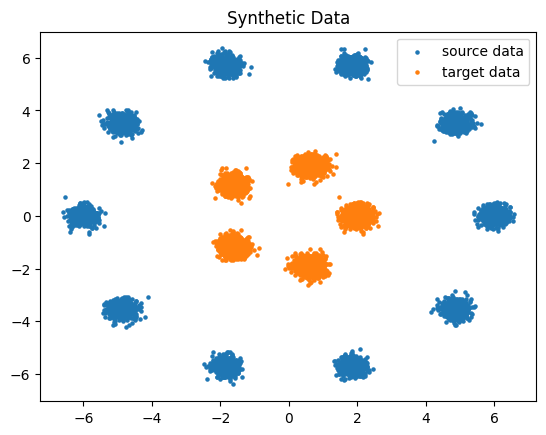

In [61]:
x3 = make_gaussians(5000, noise=0.2, radius=6.0)
y3 = make_gaussians(5000, noise=0.2, nb_gaussians=5)

plt.figure()

plt.scatter(x3[:, 0], x3[:, 1], s=5, label="source data")

plt.scatter(y3[:, 0], y3[:, 1], s=5, label="target data")
plt.legend()
plt.title("Synthetic Data")
plt.show()

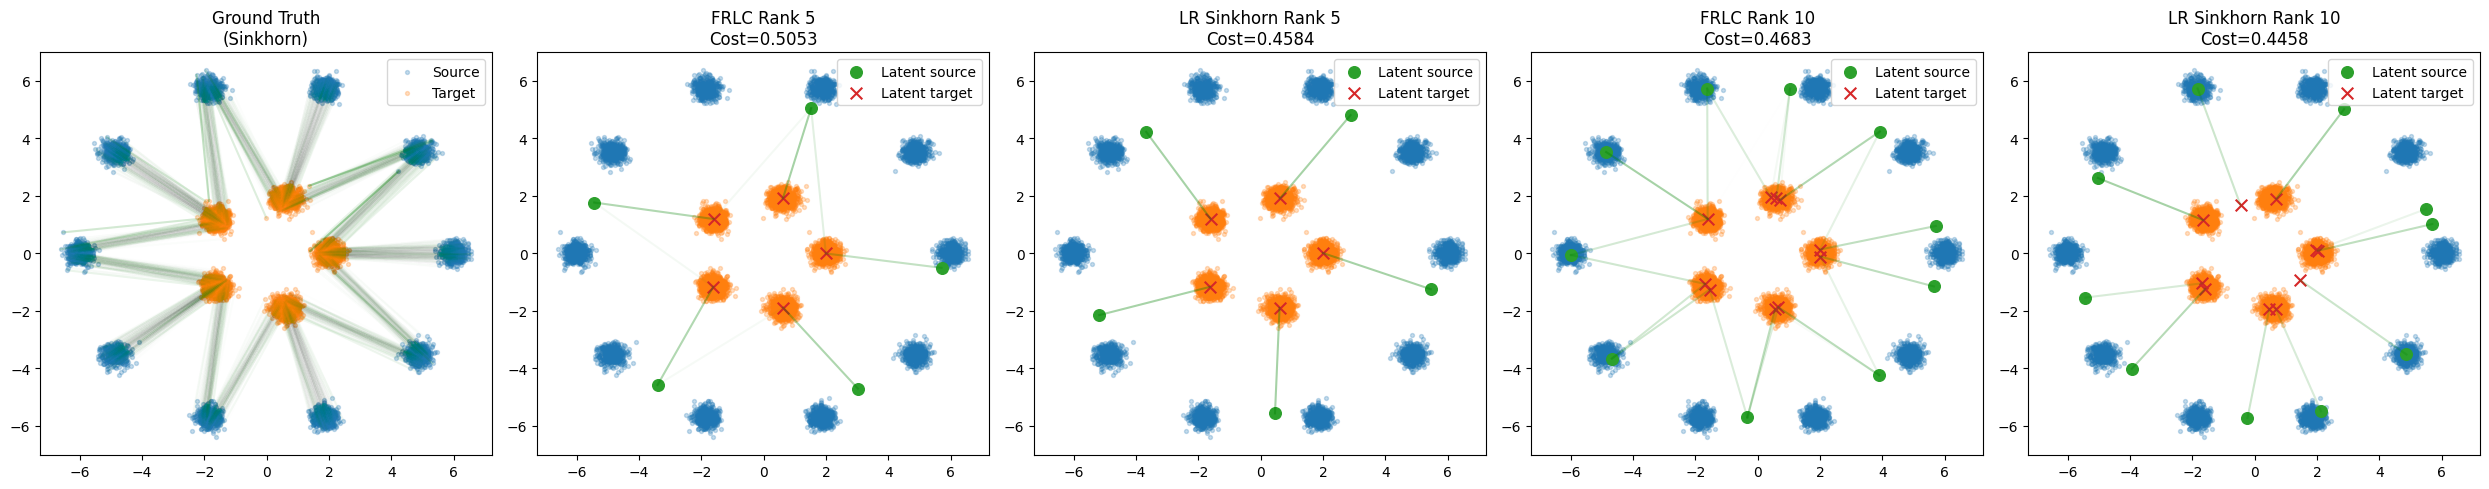

In [75]:
experiment_latent_couplings_compare(x3, y3, num_paths=5000)

We observe that FRLC latent couplings seems more interpretable than those of LR Sinkhorn, especially for rank 10.

### Experiment 4

Test the FRLC on a multi dimensional synthetic dataset.